In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import altair as alt

sns.set(style="whitegrid", palette="muted", font_scale=1.2)

def load_and_clean_enrol(filename):
    df = pd.read_csv(filename)
    df.columns = df.columns.str.strip().str.lower()
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    return df

enrol1 = load_and_clean_enrol("aadhar_enrol_1.csv")
enrol2 = load_and_clean_enrol("aadhar_enrol_2.csv")
enrol3 = load_and_clean_enrol("aadhar_enrol_3.csv")

enrol_df = pd.concat([enrol2, enrol3], ignore_index=True)
print("Combined enrolment dataset shape:", enrol_df.shape)
enrol_df.head()

Combined enrolment dataset shape: (506029, 7)


/tmp/ipython-input-2103400512.py:18: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'], errors='coerce')
/tmp/ipython-input-2103400512.py:18: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'], errors='coerce')


,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
0,2025-10-26,Andhra Pradesh,Nalgonda,508004,0,1,0
1,2025-10-26,Andhra Pradesh,Nalgonda,508238,1,0,0
2,2025-10-26,Andhra Pradesh,Nalgonda,508278,1,0,0
3,2025-10-26,Andhra Pradesh,Nandyal,518432,0,1,0
4,2025-10-26,Andhra Pradesh,Nandyal,518543,1,0,0


/tmp/ipython-input-2814755619.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=age_summary, x='Age Group', y='Count', palette="muted")


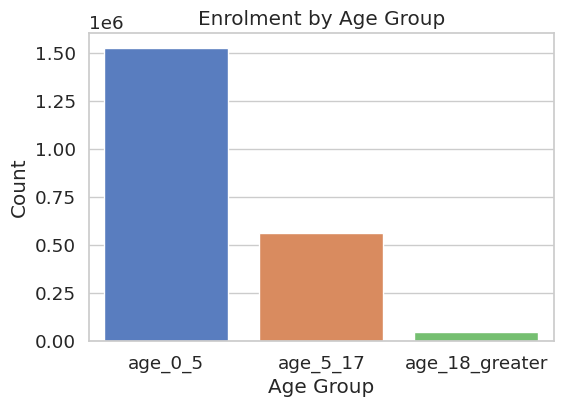

In [ ]:
age_summary = enrol_df[['age_0_5','age_5_17','age_18_greater']].sum().reset_index()
age_summary.columns = ['Age Group','Count']

plt.figure(figsize=(6,4))
sns.barplot(data=age_summary, x='Age Group', y='Count', palette="muted")
plt.title("Enrolment by Age Group")
plt.show()

<Figure size 1000x600 with 0 Axes>

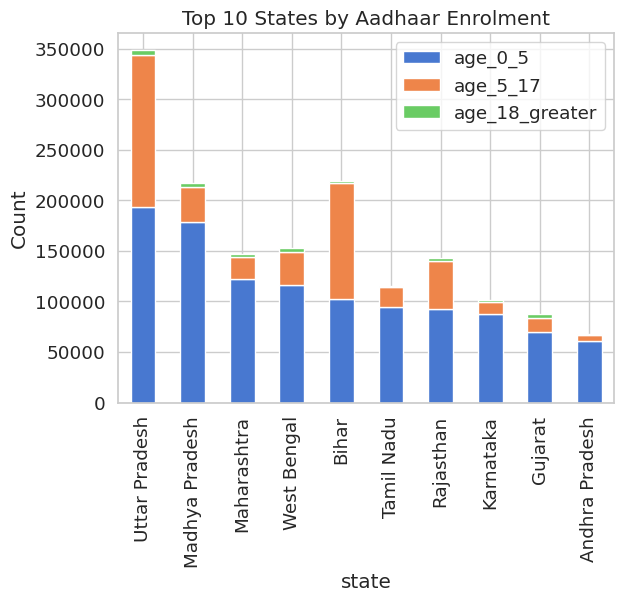

In [ ]:
state_summary = enrol_df.groupby('state')[['age_0_5','age_5_17','age_18_greater']].sum().reset_index()

top_states = state_summary.sort_values(by=['age_0_5','age_5_17','age_18_greater'], ascending=False).head(10)

plt.figure(figsize=(10,6))
top_states.set_index('state')[['age_0_5','age_5_17','age_18_greater']].plot(kind='bar', stacked=True)
plt.title("Top 10 States by Aadhaar Enrolment")
plt.ylabel("Count")
plt.show()

In [ ]:
district_summary = enrol_df.groupby(['state','district'])[['age_0_5','age_5_17','age_18_greater']].sum().reset_index()

heatmap = alt.Chart(district_summary).mark_rect().encode(
    x='district:N',
    y='state:N',
    color='age_18_greater:Q',
    tooltip=['state','district','age_0_5','age_5_17','age_18_greater']
).properties(
    width=800,
    height=600,
    title="Trivariate: Heatmap of Aadhaar Enrolment (Adults)"
)

heatmap.show()

alt.Chart(...)

Number of anomalous districts: 2665
Top anomalies:
          state         district  pincode  age_5_17  age_18_greater  \
70        Assam          Darrang   784146         1               4   
384   Karnataka  Bangalore Rural   560087         0               3   
2078      Assam     Kamrup Metro   781034         0               3   
2480      Assam          Darrang   784146         0               4   
2481      Assam          Dhemaji   787060         1               6   
2489      Assam        Dibrugarh   786610         0               6   
2492      Assam         Golaghat   785612         1               7   
2494      Assam         Golaghat   785625         0               4   
2537      Assam         Sibsagar   785701         0               3   
2681      Bihar        Sitamarhi   843330         0               3   

      ratio_adult_youth  
70                  4.0  
384                 3.0  
2078                3.0  
2480                4.0  
2481                6.0  
2489       

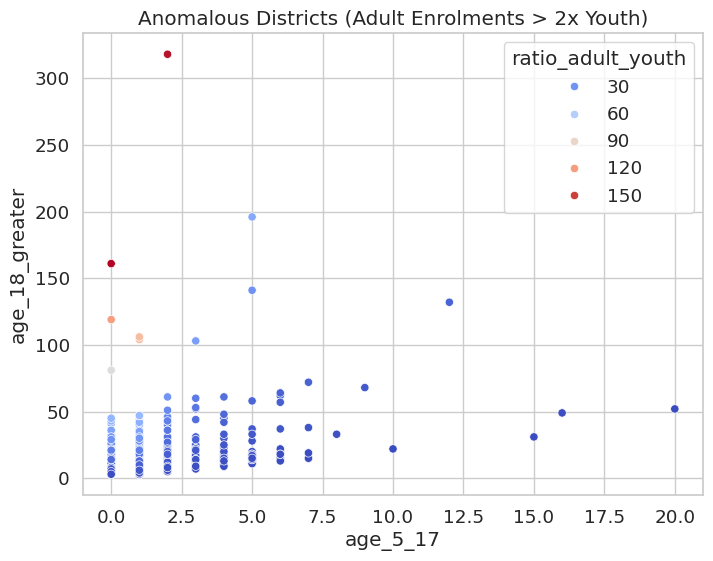

In [ ]:
# Ratio of adult to youth enrolments
enrol_df['ratio_adult_youth'] = enrol_df['age_18_greater'] / (enrol_df['age_5_17'].replace(0, 1))

anomalies = enrol_df[enrol_df['ratio_adult_youth'] > 2]

print("Number of anomalous districts:", len(anomalies))
print("Top anomalies:")
print(anomalies[['state','district','pincode','age_5_17','age_18_greater','ratio_adult_youth']].head(10))

plt.figure(figsize=(8,6))
sns.scatterplot(data=anomalies, x='age_5_17', y='age_18_greater', hue='ratio_adult_youth', palette="coolwarm")
plt.title("Anomalous Districts (Adult Enrolments > 2x Youth)")
plt.show()

In [ ]:
total_infants = enrol_df['age_0_5'].sum()
total_youth = enrol_df['age_5_17'].sum()
total_adults = enrol_df['age_18_greater'].sum()

top_youth_state = enrol_df.groupby('state')['age_5_17'].sum().idxmax()
top_adult_state = enrol_df.groupby('state')['age_18_greater'].sum().idxmax()

print(" Key Insights (Enrolment):")
print(f"- Total enrolments: Infants={total_infants}, Youth={total_youth}, Adults={total_adults}.")
print(f"- {top_youth_state} leads in youth enrolments.")
print(f"- {top_adult_state} leads in adult enrolments.")
print(f"- {len(anomalies)} districts show adult enrolments more than double youth enrolments.")
print("- These anomalies may indicate targeted adult enrolment drives or gaps in youth enrolment campaigns.")

 Key Insights (Enrolment):
- Total enrolments: Infants=1526559, Youth=562543, Adults=45574.
- Uttar Pradesh leads in youth enrolments.
- Assam leads in adult enrolments.
- 2665 districts show adult enrolments more than double youth enrolments.
- These anomalies may indicate targeted adult enrolment drives or gaps in youth enrolment campaigns.


In [ ]:
from google.colab import files

enrol_df.to_csv("enrolment_master.csv", index=False)
files.download("enrolment_master.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>